In [2]:
%pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn  openpyxl ydata-profiling skrebate catboost kagglehub

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold,train_test_split
from sklearn.metrics import (
    precision_recall_curve, average_precision_score, roc_auc_score,
    f1_score, recall_score, precision_score, classification_report, confusion_matrix,PrecisionRecallDisplay
)
# Resamplers
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import SMOTENC
from imblearn.combine import SMOTEENN
from sklearn.compose import ColumnTransformer
from catboost import CatBoostClassifier, Pool
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
import os, kagglehub

c:\Users\Farrukh\anaconda3\envs\fraud_detection\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Download latest version
path = kagglehub.dataset_download("rohitrox/healthcare-provider-fraud-detection-analysis")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Farrukh\.cache\kagglehub\datasets\rohitrox\healthcare-provider-fraud-detection-analysis\versions\1


In [5]:
data_path = r"D:\Final year project\1"
inpatient_df = pd.read_csv(os.path.join(data_path, "Train_Inpatientdata.csv"))
outpatient_df = pd.read_csv(os.path.join(data_path, "Train_Outpatientdata.csv"))
beneficiary_df = pd.read_csv(os.path.join(data_path, "Train_Beneficiarydata.csv"))
train_df = pd.read_csv(os.path.join(data_path, "Train.csv"))

In [6]:
# Function to check missing values
def check_missing(df, name):
    print(f"\nMissing Values in {name}:")
    missing = df.isnull().mean()*100
    missing = missing[missing > 0].sort_values(ascending=False)
    if missing.empty:
        print("✅ No missing values")
    else:
        print(missing)

# Check for each dataset
check_missing(inpatient_df, "Inpatient Data")
check_missing(outpatient_df, "Outpatient Data")
check_missing(beneficiary_df, "Beneficiary Data")
check_missing(train_df, "Train Data")



Missing Values in Inpatient Data:
ClmProcedureCode_6     100.000000
ClmProcedureCode_5      99.977764
ClmProcedureCode_4      99.713396
ClmProcedureCode_3      97.615753
ClmDiagnosisCode_10     90.297475
OtherPhysician          88.412314
ClmProcedureCode_2      86.524683
ClmProcedureCode_1      42.807728
OperatingPhysician      41.122696
ClmDiagnosisCode_9      33.347334
ClmDiagnosisCode_8      24.563918
ClmDiagnosisCode_7      17.932500
ClmDiagnosisCode_6      11.953353
ClmDiagnosisCode_5       7.150269
ClmDiagnosisCode_4       3.790087
DeductibleAmtPaid        2.221179
ClmDiagnosisCode_3       1.670208
ClmDiagnosisCode_2       0.558383
AttendingPhysician       0.276721
dtype: float64

Missing Values in Outpatient Data:
ClmProcedureCode_6       100.000000
ClmProcedureCode_5       100.000000
ClmProcedureCode_4        99.999614
ClmProcedureCode_3        99.999227
ClmProcedureCode_2        99.993047
ClmProcedureCode_1        99.968710
ClmDiagnosisCode_10       99.790820
ClmDiagnosisCode

In [7]:
outpatient_df["ClmAdmitDiagnosisCode"].isna().mean() * 100



np.float64(79.63734482951769)

In [8]:
#handling missing values
# Step: Fill missing values in DeductibleAmtPaid
# 1. Compute median of DeductibleAmtPaid
# 2. Fill NaNs with that median
deductible_median = inpatient_df["DeductibleAmtPaid"].median()
inpatient_df["DeductibleAmtPaid"] = inpatient_df["DeductibleAmtPaid"].fillna(deductible_median)
outpatient_df["DeductibleAmtPaid"] = outpatient_df["DeductibleAmtPaid"].fillna(deductible_median)
# claim_procedur code missing values
proc_cols = [f"ClmProcedureCode_{i}" for i in range(1, 7)]
inpatient_df[proc_cols] = inpatient_df[proc_cols].fillna("None")
outpatient_df[proc_cols] = outpatient_df[proc_cols].fillna("None")
##claim diagnosis cod emissing values
diag_cols = [f"ClmDiagnosisCode_{i}" for i in range(1,11)]
inpatient_df[diag_cols] = inpatient_df[diag_cols].fillna("None")
outpatient_df[diag_cols] = outpatient_df[diag_cols].fillna("None")
# Operating physicin NPI and OtherPhysician NPI missing values
inpatient_df["OperatingPhysician"] = inpatient_df["OperatingPhysician"].fillna("None")
inpatient_df["OtherPhysician"] = inpatient_df["OtherPhysician"].fillna("None")
inpatient_df["AttendingPhysician"] = inpatient_df["AttendingPhysician"].fillna("None")
outpatient_df["OperatingPhysician"] = outpatient_df["OperatingPhysician"].fillna("None")
outpatient_df["OtherPhysician"] = outpatient_df["OtherPhysician"].fillna("None")
outpatient_df["AttendingPhysician"] = outpatient_df["AttendingPhysician"].fillna("None")

# Fill missing admit diagnosis code in both inpatient and outpatient
inpatient_df["ClmAdmitDiagnosisCode"] = inpatient_df["ClmAdmitDiagnosisCode"].fillna("Unknown")
outpatient_df["ClmAdmitDiagnosisCode"] = outpatient_df["ClmAdmitDiagnosisCode"].fillna("Unknown")



#handle misisng in DOD in beneficiary
beneficiary_df['DOD'] = beneficiary_df['DOD'].fillna('None')


In [9]:
# Check for each dataset
check_missing(inpatient_df, "Inpatient Data")
check_missing(outpatient_df, "Outpatient Data")
check_missing(beneficiary_df, "Beneficiary Data")
check_missing(train_df, "Train Data")


Missing Values in Inpatient Data:
✅ No missing values

Missing Values in Outpatient Data:
✅ No missing values

Missing Values in Beneficiary Data:
✅ No missing values

Missing Values in Train Data:
✅ No missing values


In [10]:
Inpatient_df = pd.merge( inpatient_df, beneficiary_df, on= 'BeneID', how= 'inner')
Inpatient_df = pd.merge( Inpatient_df , train_df , on = "Provider" , how = 'left')
Outpatient_df = pd.merge( outpatient_df, beneficiary_df, on= 'BeneID', how= 'inner')
Outpatient_df = pd.merge(Outpatient_df,train_df, on='Provider', how= 'left')
claims_df = pd.concat([Inpatient_df, Outpatient_df], ignore_index= True)

In [11]:
claims_df['PotentialFraud']

0         Yes
1          No
2          No
3          No
4          No
         ... 
558206     No
558207     No
558208     No
558209     No
558210     No
Name: PotentialFraud, Length: 558211, dtype: object

In [12]:
claims_df['PotentialFraud'] = claims_df['PotentialFraud'].map({'Yes': 1, 'No': 0})

In [13]:
claims_df['PotentialFraud']

0         1
1         0
2         0
3         0
4         0
         ..
558206    0
558207    0
558208    0
558209    0
558210    0
Name: PotentialFraud, Length: 558211, dtype: int64

In [14]:
# Count number of fraud and non-fraud cases
fraud_counts = claims_df['PotentialFraud'].value_counts()
print(fraud_counts)

PotentialFraud
0    345415
1    212796
Name: count, dtype: int64


In [15]:
Clean_df = claims_df.copy()

In [16]:
check_missing(Clean_df, 'Claims data')


Missing Values in Claims data:
AdmissionDt           92.749337
DischargeDt           92.749337
DiagnosisGroupCode    92.749337
dtype: float64


In [17]:
# Feature Engineering
# Claim date to datetime
Clean_df["ClaimStartDt"] = pd.to_datetime(Clean_df["ClaimStartDt"], errors="coerce")
Clean_df["ClaimEndDt"]   = pd.to_datetime(Clean_df["ClaimEndDt"], errors="coerce")
Clean_df["AdmissionDt"]   = pd.to_datetime(Clean_df["AdmissionDt"], errors="coerce")
Clean_df["DischargeDt"]   = pd.to_datetime(Clean_df["DischargeDt"], errors="coerce")
Clean_df["DOB"]   = pd.to_datetime(Clean_df["DOB"], errors="coerce")
Clean_df["DOD"]   = pd.to_datetime(Clean_df["DOD"], errors="coerce")
# Calculate claim duration in 
Clean_df['Claim_Duration'] = (Clean_df["ClaimEndDt"] - Clean_df["ClaimStartDt"]).dt.days
Clean_df['Lengthofstay'] = (Clean_df["DischargeDt"] - Clean_df["AdmissionDt"]).dt.days
# Age at time of claim (in years)
age_timedelta = Clean_df["ClaimStartDt"] - Clean_df["DOB"]
Clean_df["Age"] = (age_timedelta.dt.days / 365.25).astype("int")


# IsDead: 1 if DOD is not null, else 0
Clean_df["IsDead"] = Clean_df["DOD"].notna().astype("int")
print(Clean_df[["ClaimStartDt", "ClaimEndDt", "Claim_Duration", "Age","Lengthofstay", "IsDead"]].head())

  ClaimStartDt ClaimEndDt  Claim_Duration  Age  Lengthofstay  IsDead
0   2009-04-12 2009-04-18               6   66           6.0       0
1   2009-08-31 2009-09-02               2   66           2.0       0
2   2009-09-17 2009-09-20               3   66           3.0       0
3   2009-02-14 2009-02-22               8   94           8.0       0
4   2009-08-13 2009-08-30              17   71          17.0       0


C:\Users\Farrukh\AppData\Local\Temp\ipykernel_15980\3853111347.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  Clean_df["DOD"]   = pd.to_datetime(Clean_df["DOD"], errors="coerce")


In [103]:
# --- 1) Per-claim money features
Clean_df["Annual_Reimb_Total"]  = Clean_df["IPAnnualReimbursementAmt"] + Clean_df["OPAnnualReimbursementAmt"]
Clean_df["Annual_Deduct_Total"] = Clean_df["IPAnnualDeductibleAmt"]    + Clean_df["OPAnnualDeductibleAmt"]
# List of annual reimbursement & deductible columns
drop_col = [
    "IPAnnualReimbursementAmt",
    "OPAnnualReimbursementAmt",
    "IPAnnualDeductibleAmt",
    "OPAnnualDeductibleAmt",
   "ClaimStartDt",
   "ClaimEndDt",
   "DOD",
   "DOB",
   "AdmissionDt",
   "DischargeDt"
]

# Drop them if they exist
Clean_df = Clean_df.drop(columns=[c for c in drop_col if c in Clean_df.columns])


print("Dropped reimbursement ,deductible and Date columns successfully.")


Dropped reimbursement ,deductible and Date columns successfully.


In [104]:
Clean_df["RenalDiseaseIndicator"] = (Clean_df["RenalDiseaseIndicator"] == "Y").astype(int)
print(Clean_df["RenalDiseaseIndicator"].head())
#State & County: codes stored as ints -> treat as categorical strings
for c in ["State", "County"]:
    if c in Clean_df.columns and pd.api.types.is_integer_dtype(Clean_df[c]):
        # keep NA if present, then convert to string dtype
        Clean_df[c] = Clean_df[c].astype("Int64").astype("string")


0    0
1    0
2    0
3    0
4    1
Name: RenalDiseaseIndicator, dtype: int64


In [105]:
Clean_df.columns

Index(['BeneID', 'ClaimID', 'Provider', 'InscClaimAmtReimbursed',
       'AttendingPhysician', 'OperatingPhysician', 'OtherPhysician',
       'ClmAdmitDiagnosisCode', 'DeductibleAmtPaid', 'DiagnosisGroupCode',
       'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3',
       'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6',
       'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8', 'ClmDiagnosisCode_9',
       'ClmDiagnosisCode_10', 'ClmProcedureCode_1', 'ClmProcedureCode_2',
       'ClmProcedureCode_3', 'ClmProcedureCode_4', 'ClmProcedureCode_5',
       'ClmProcedureCode_6', 'Gender', 'Race', 'RenalDiseaseIndicator',
       'State', 'County', 'NoOfMonths_PartACov', 'NoOfMonths_PartBCov',
       'ChronicCond_Alzheimer', 'ChronicCond_Heartfailure',
       'ChronicCond_KidneyDisease', 'ChronicCond_Cancer',
       'ChronicCond_ObstrPulmonary', 'ChronicCond_Depression',
       'ChronicCond_Diabetes', 'ChronicCond_IschemicHeart',
       'ChronicCond_Osteoporasis', 'Chr

In [19]:
Clean_df["total_claim_amt"] = Clean_df["InscClaimAmtReimbursed"] + Clean_df["DeductibleAmtPaid"]
Clean_df["high_cost_flag"] = Clean_df["total_claim_amt"] > Clean_df["total_claim_amt"].quantile(0.95)

In [20]:
Clean_df["reimb_ratio"] = Clean_df["InscClaimAmtReimbursed"] / Clean_df["total_claim_amt"]
# procedure codes engineering
proc_cols = [c for c in Clean_df.columns if "ClmProcedureCode" in c]

Clean_df["procedure_count"] = Clean_df[proc_cols].notna().sum(axis=1)
# rare procedure flag
all_procs = Clean_df[proc_cols].values.ravel()
proc_freq = pd.Series(all_procs).value_counts()

Clean_df["rare_procedure_score"] = Clean_df[proc_cols].apply(
    lambda x: sum(proc_freq.get(i, 0) for i in x if pd.notnull(i)),
    axis=1
)

In [21]:
# Diagnosis per count
diag_cols = [c for c in Clean_df.columns if "ClmDiagnosisCode" in c]

Clean_df["diagnosis_count"] = Clean_df[diag_cols].notna().sum(axis=1)

In [22]:
# chronic disease burden score
chronic_cols = [c for c in Clean_df.columns if "ChronicCond" in c]

Clean_df["chronic_burden"] = Clean_df[chronic_cols].sum(axis=1)

In [23]:
#Claims per provider
Clean_df["provider_claim_count"] = Clean_df.groupby("Provider")["Provider"].transform("count")

In [24]:
# high risk provider
Clean_df["high_risk_provider"] = Clean_df["provider_claim_count"] > Clean_df["provider_claim_count"].quantile(0.95)

In [25]:
#Physician mismatch
Clean_df["physician_mismatch"] = (Clean_df["AttendingPhysician"] != Clean_df["OperatingPhysician"]).astype(int)

In [26]:
#Long stay flag
Clean_df["long_stay_flag"] = Clean_df["Lengthofstay"] > Clean_df["Lengthofstay"].quantile(0.95)

In [28]:
# duration inconsistencies
Clean_df["duration_per_cost"] = Clean_df["total_claim_amt"] / (Clean_df["Claim_Duration"] + 1)

In [29]:
#Fraud risk score
Clean_df["fraud_risk_score"] =(
        
        Clean_df["high_cost_flag"].astype(int) + 
        Clean_df["rare_procedure_score"] +
        Clean_df["physician_mismatch"] +
        Clean_df["long_stay_flag"].astype(int)
        
     ) 

In [31]:
Clean_df.to_csv("cleaned_data.csv", index=False)

In [ ]:

cols_to_drop = [c for c in Clean_df.columns
                if c.startswith('ClmDiagnosisCode_') or c.startswith('ClmProcedureCode_')]

Clean_df_lr = Clean_df.drop(columns=cols_to_drop)   # keep a copy for the LR model
print(f"Dropped {len(cols_to_drop)} cols:", cols_to_drop[:10], "...")
print("New shape:", Clean_df_lr.shape)



Dropped 16 cols: ['ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3', 'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6', 'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8', 'ClmDiagnosisCode_9', 'ClmDiagnosisCode_10'] ...
New shape: (558211, 35)


In [107]:
# Traget and predictors
Ids = ['ClaimID', 'BeneID', 'Provider','AttendingPhysician','OperatingPhysician','OtherPhysician']
df = Clean_df_lr.drop(columns = [c for c in Clean_df_lr.columns if c in Ids])
df.head()

,InscClaimAmtReimbursed,ClmAdmitDiagnosisCode,DeductibleAmtPaid,DiagnosisGroupCode,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,...,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,PotentialFraud,Claim_Duration,Lengthofstay,Age,IsDead,Annual_Reimb_Total,Annual_Deduct_Total
0,26000,7866,1068.0,201,1,1,0,39,230,12,...,2,1,1,1,6,6.0,66,0,36060,3274
1,5000,6186,1068.0,750,1,1,0,39,230,12,...,2,1,1,0,2,2.0,66,0,36060,3274
2,5000,29590,1068.0,883,1,1,0,39,230,12,...,2,1,1,0,3,3.0,66,0,36060,3274
3,5000,431,1068.0,067,2,2,0,1,360,12,...,2,1,1,0,8,8.0,94,0,5250,1388
4,10000,78321,1068.0,975,2,1,1,45,780,12,...,2,2,2,0,17,17.0,71,0,21380,2236


In [108]:
df.dtypes

InscClaimAmtReimbursed                      int64
ClmAdmitDiagnosisCode                      object
DeductibleAmtPaid                         float64
DiagnosisGroupCode                         object
Gender                                      int64
Race                                        int64
RenalDiseaseIndicator                       int64
State                              string[python]
County                             string[python]
NoOfMonths_PartACov                         int64
NoOfMonths_PartBCov                         int64
ChronicCond_Alzheimer                       int64
ChronicCond_Heartfailure                    int64
ChronicCond_KidneyDisease                   int64
ChronicCond_Cancer                          int64
ChronicCond_ObstrPulmonary                  int64
ChronicCond_Depression                      int64
ChronicCond_Diabetes                        int64
ChronicCond_IschemicHeart                   int64
ChronicCond_Osteoporasis                    int64


In [109]:
print(df['ClmAdmitDiagnosisCode'].nunique())


4099


In [110]:
y = df['PotentialFraud']
X = df.drop(['PotentialFraud'], axis =1)

# splitting into TRain and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  
)


In [111]:
X_train.dtypes

InscClaimAmtReimbursed                      int64
ClmAdmitDiagnosisCode                      object
DeductibleAmtPaid                         float64
DiagnosisGroupCode                         object
Gender                                      int64
Race                                        int64
RenalDiseaseIndicator                       int64
State                              string[python]
County                             string[python]
NoOfMonths_PartACov                         int64
NoOfMonths_PartBCov                         int64
ChronicCond_Alzheimer                       int64
ChronicCond_Heartfailure                    int64
ChronicCond_KidneyDisease                   int64
ChronicCond_Cancer                          int64
ChronicCond_ObstrPulmonary                  int64
ChronicCond_Depression                      int64
ChronicCond_Diabetes                        int64
ChronicCond_IschemicHeart                   int64
ChronicCond_Osteoporasis                    int64


In [112]:
OHE = OneHotEncoder(handle_unknown='ignore')

numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = ['ClmAdmitDiagnosisCode','State','County','DiagnosisGroupCode']
Categorical_data = X_train[categorical_cols]
categorical_data_test = X_test[categorical_cols]


# 3. Fit the encoder on X_train, and transform it
X_encoded =OHE.fit_transform(Categorical_data)
X_test_encode = OHE.transform(categorical_data_test)

In [113]:
from sklearn.decomposition import TruncatedSVD
# Create a TruncatedSVD object with  components


svd = TruncatedSVD(n_components=60)
X_train_reduced = svd.fit_transform(X_encoded)
X_test_reduced = svd.transform(X_test_encode)

total_variance = svd.explained_variance_ratio_.sum()
print(f"Total variance retained: {total_variance:.4f}")



Total variance retained: 0.6385


In [114]:
from sklearn.preprocessing import StandardScaler
X_train[numeric_cols] = X_train[numeric_cols].fillna(0)
X_test[numeric_cols] = X_test[numeric_cols].fillna(0)


scaler = StandardScaler()
X_numeric_scaled = scaler.fit_transform(X_train[numeric_cols])
X_test_numeric_scaled = scaler.transform(X_test[numeric_cols])

X_train_final = np.concatenate([X_numeric_scaled, X_train_reduced], axis=1)
X_test_final = np.concatenate([X_test_numeric_scaled, X_test_reduced], axis =1)


In [115]:
np.where(np.isnan(X_train_final))


(array([], dtype=int64), array([], dtype=int64))

In [ ]:
# 1️⃣ Get encoded feature names from OneHotEncoder
encoded_feature_names = OHE.get_feature_names_out(categorical_cols)

# 2️⃣ Combine all final feature names
# numeric + encoded +  reduced components
feature_names = list(numeric_cols) + list(encoded_feature_names)
# since TruncatedSVD is used to reduce encoded data, adjusting names:
feature_names_reduced = [f"SVD_Component_{i+1}" for i in range(X_train_reduced.shape[1])]
# final combined names (numeric + reduced)
final_feature_names = list(numeric_cols) + feature_names_reduced


In [117]:
# Logistic regression model

Lr_model = LogisticRegression(class_weight = 'balanced', max_iter= 1000)
Lr_model.fit(X_train_final,y_train)
y_pred = Lr_model.predict(X_test_final)

In [118]:

X_train_final = pd.DataFrame(X_train_final, columns=final_feature_names)

coef_table = pd.DataFrame({
    'Feature': X_train_final.columns,
    'Coefficient': Lr_model.coef_[0]
})

#  Sort to see most influential features
coef_table = coef_table.sort_values(by='Coefficient', ascending=False).reset_index(drop=True)

#  Display
print(coef_table.head(50))

                     Feature  Coefficient
0           SVD_Component_47     1.223643
1           SVD_Component_49     1.132957
2           SVD_Component_46     1.085091
3           SVD_Component_18     1.010020
4           SVD_Component_17     0.953339
5           SVD_Component_16     0.951543
6            SVD_Component_2     0.838506
7           SVD_Component_13     0.782995
8            SVD_Component_5     0.757634
9           SVD_Component_55     0.669416
10          SVD_Component_51     0.657787
11          SVD_Component_36     0.627243
12          SVD_Component_28     0.619252
13          SVD_Component_26     0.610606
14           SVD_Component_8     0.570186
15          SVD_Component_60     0.565549
16          SVD_Component_56     0.545958
17          SVD_Component_35     0.473656
18          SVD_Component_40     0.469246
19           SVD_Component_9     0.421135
20           SVD_Component_3     0.339650
21           SVD_Component_6     0.298999
22           SVD_Component_4     0

In [119]:
# evaluation of logistic regression 
y_proba = Lr_model.predict_proba(X_test_final)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

# Compute F1 for each threshold
f1 = 2 * (precision * recall) / (precision + recall)

# Find index of max F1
best_index = f1.argmax()
best_threshold = thresholds[best_index]

print(f"Best Threshold: {best_threshold:.3f}")




Best Threshold: 0.445


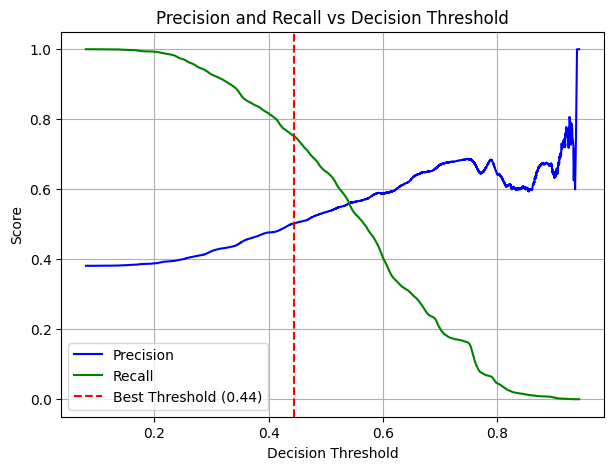

In [120]:


plt.figure(figsize=(7,5))
plt.plot(thresholds, precision[:-1], label='Precision', color='blue')
plt.plot(thresholds, recall[:-1], label='Recall', color='green')
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Best Threshold ({best_threshold:.2f})')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Precision and Recall vs Decision Threshold')
plt.legend()
plt.grid(True)
plt.show()


In [121]:


# Apply best threshold
y_pred_opt = (y_proba >= best_threshold).astype(int)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_opt)
tn, fp, fn, tp = cm.ravel()

# Compute metrics
precision_val = precision_score(y_test, y_pred_opt)
recall_val = recall_score(y_test, y_pred_opt)
f1_val = f1_score(y_test, y_pred_opt)
roc_auc_val = roc_auc_score(y_test, y_proba)
pr_auc_val = average_precision_score(y_test, y_proba)

# Print vertically formatted results
print("\n===== Logistic Regression Evaluation (Threshold Optimized) =====")
print(f"Best Threshold : {best_threshold:.3f}")
print("\n----- Confusion Matrix Details -----")
print(f"True Negatives : {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives : {tp}")

print("\n----- Model Performance Metrics -----")
print(f"Precision      : {precision_val:.3f}")
print(f"Recall         : {recall_val:.3f}")
print(f"F1 Score       : {f1_val:.3f}")
print(f"ROC-AUC Score  : {roc_auc_val:.3f}")
print(f"PR-AUC Score   : {pr_auc_val:.3f}")





===== Logistic Regression Evaluation (Threshold Optimized) =====
Best Threshold : 0.445

----- Confusion Matrix Details -----
True Negatives : 37485
False Positives: 31598
False Negatives: 10583
True Positives : 31977

----- Model Performance Metrics -----
Precision      : 0.503
Recall         : 0.751
F1 Score       : 0.603
ROC-AUC Score  : 0.697
PR-AUC Score   : 0.562


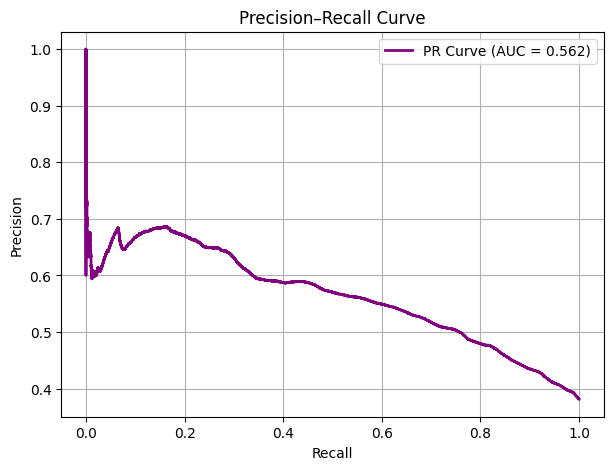

In [122]:
#PR-AUC curve

# Compute precision and recall at all thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

# Compute PR-AUC (area under the Precision–Recall curve)

pr_auc = average_precision_score(y_test, y_proba)

# Plot the Precision–Recall curve
plt.figure(figsize=(7,5))
plt.plot(recall, precision, color='purple', linewidth=2, label=f"PR Curve (AUC = {pr_auc:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend()
plt.grid(True)
plt.show()


In [123]:
# Fill NaNs in categorical columns before training
X_train[categorical_cols] = X_train[categorical_cols].fillna("Missing")
X_test[categorical_cols] = X_test[categorical_cols].fillna("Missing")

Cat_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    eval_metric='F1',
    random_seed=42,
    verbose=100
)

Cat_model.fit(X_train, y_train, cat_features=categorical_cols, eval_set=(X_test, y_test), early_stopping_rounds=50)



0:	learn: 0.6989894	test: 0.7036154	best: 0.7036154 (0)	total: 1.28s	remaining: 21m 22s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7036154341
bestIteration = 0

Shrink model to first 1 iterations.


In [124]:
y_pred_cat = Cat_model.predict(X_test)
y_proba_cat = Cat_model.predict_proba(X_test)[:, 1]

cat_cm= confusion_matrix(y_test, y_pred_cat)
print("Confusion Matrix:\n", cat_cm)
precision_cat = precision_score(y_test, y_pred_cat)
print("Precision:", precision_cat)
recall_cat = recall_score(y_test, y_pred_cat)
print("Recall:", recall_cat)
roc_auc_cat = roc_auc_score(y_test, y_proba_cat)
print("ROC-AUC Score:", roc_auc_cat)
pr_auc_cat = average_precision_score(y_test, y_proba_cat)
print("PR-AUC Score:", pr_auc_cat)

Confusion Matrix:
 [[57248 11835]
 [13037 29523]]
Precision: 0.7138401276657479
Recall: 0.6936795112781955
ROC-AUC Score: 0.8354088260835636
PR-AUC Score: 0.7262284987031077


In [125]:
# train catBoost 
from collections import Counter

counter = Counter(y_train)
majority = counter[0]
minority = counter[1]

class_weights = {0: 1.0, 1: majority / minority}
print(class_weights)

# Fill NaNs in categorical columns before training
X_train[categorical_cols] = X_train[categorical_cols].fillna("Missing")
X_test[categorical_cols] = X_test[categorical_cols].fillna("Missing")

model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    class_weights=class_weights,
    eval_metric='F1',
    random_seed=42,
    verbose=100
)

model.fit(X_train, y_train, cat_features=categorical_cols, eval_set=(X_test, y_test), early_stopping_rounds=50)



{0: 1.0, 1: 1.6232289292511572}
0:	learn: 0.7657978	test: 0.7696506	best: 0.7696506 (0)	total: 1s	remaining: 16m 41s
100:	learn: 0.7674932	test: 0.7719313	best: 0.7720874 (85)	total: 1m	remaining: 8m 56s
200:	learn: 0.7684865	test: 0.7732960	best: 0.7732993 (199)	total: 2m	remaining: 7m 59s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7733591463
bestIteration = 218

Shrink model to first 219 iterations.


In [126]:
y_pred_cb = model.predict(X_test)
y_proba_cb = model.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred_cb)
print("Confusion Matrix:\n", cm)
precision_cb = precision_score(y_test, y_pred_cb)
print("Precision:", precision_cb)
recall_cb = recall_score(y_test, y_pred_cb)
print("Recall:", recall_cb)
roc_auc_cb = roc_auc_score(y_test, y_proba_cb)
print("ROC-AUC Score:", roc_auc_cb)
pr_auc_cb = average_precision_score(y_test, y_proba_cb)
print("PR-AUC Score:", pr_auc_cb)

Confusion Matrix:
 [[53977 15106]
 [ 9860 32700]]
Precision: 0.6840145588419864
Recall: 0.7683270676691729
ROC-AUC Score: 0.855170390207856
PR-AUC Score: 0.7838462074603052


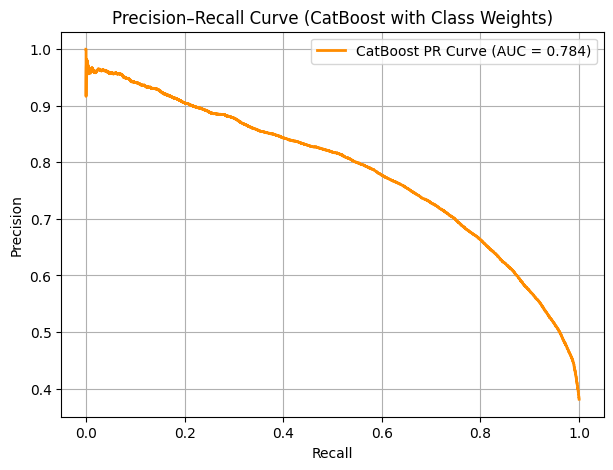

In [127]:
# 1️⃣ Compute precision, recall, and thresholds
precision_cb, recall_cb, thresholds_cb = precision_recall_curve(y_test, y_proba_cb)

# 3️⃣ Plot the Precision–Recall curve
plt.figure(figsize=(7,5))
plt.plot(recall_cb, precision_cb, color='darkorange', linewidth=2,
         label=f"CatBoost PR Curve (AUC = {pr_auc_cb:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (CatBoost with Class Weights)")
plt.legend()
plt.grid(True)
plt.show()

In [128]:
# Applying Random undersampling
xy_train = pd.concat([X_train,y_train], axis =1)
# Separate the classes
majority_class = xy_train[xy_train['PotentialFraud'] == 0]
minority_class = xy_train[xy_train['PotentialFraud'] == 1]

# Downsample majority to match minority count
majority_downsampled = majority_class.sample(len(minority_class), random_state=42)

# Combine back to get balanced training set
Xy_balanced = pd.concat([majority_downsampled, minority_class])

# Shuffle the data
Xy_balanced = Xy_balanced.sample(frac=1, random_state=42)

# Separate X and y again
X_train_balanced = Xy_balanced.drop('PotentialFraud', axis=1)
y_train_balanced = Xy_balanced['PotentialFraud']


In [129]:
X_train_balanced[categorical_cols] = X_train_balanced[categorical_cols].fillna("Missing")
X_test[categorical_cols] = X_test[categorical_cols].fillna("Missing")


C:\Users\Farrukh\AppData\Local\Temp\ipykernel_6616\2556889049.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette=['#66c2a5', '#fc8d62'])


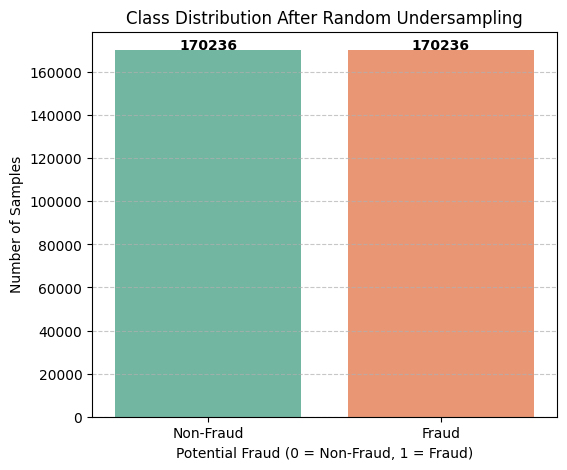

In [130]:

# Count of each class in the balanced dataset
class_counts = Xy_balanced['PotentialFraud'].value_counts()

# Plot
plt.figure(figsize=(6,5))
sns.barplot(x=class_counts.index, y=class_counts.values, palette=['#66c2a5', '#fc8d62'])

plt.title("Class Distribution After Random Undersampling")
plt.xlabel("Potential Fraud (0 = Non-Fraud, 1 = Fraud)")
plt.ylabel("Number of Samples")
plt.xticks([0, 1], ['Non-Fraud', 'Fraud'])
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show values on top of bars
for i, value in enumerate(class_counts.values):
    plt.text(i, value + 100, str(value), ha='center', fontweight='bold')

plt.show()


In [131]:


cat_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    eval_metric='F1',
    random_seed=42,
    verbose=100
)

cat_model.fit(
    X_train_balanced, y_train_balanced,
    cat_features=categorical_cols,
    eval_set=(X_test, y_test),
    early_stopping_rounds=50
)


0:	learn: 0.7592111	test: 0.7161640	best: 0.7161640 (0)	total: 1.12s	remaining: 18m 39s
100:	learn: 0.7643803	test: 0.7199815	best: 0.7200132 (73)	total: 1m 9s	remaining: 10m 23s
200:	learn: 0.7658880	test: 0.7226934	best: 0.7227758 (198)	total: 2m 15s	remaining: 8m 56s
300:	learn: 0.7668411	test: 0.7240155	best: 0.7240174 (287)	total: 3m 14s	remaining: 7m 30s
400:	learn: 0.7678907	test: 0.7241949	best: 0.7243017 (385)	total: 4m 36s	remaining: 6m 52s
500:	learn: 0.7682199	test: 0.7246679	best: 0.7249051 (488)	total: 5m 35s	remaining: 5m 34s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7249050823
bestIteration = 488

Shrink model to first 489 iterations.


In [132]:
y_pred_rus = cat_model.predict(X_test)
y_proba_rus = cat_model.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred_rus)
print("Confusion Matrix Of RandomUndersampling CatBoost:\n", cm)
precision_Rus = precision_score(y_test, y_pred_rus)
print("Precision Of RandomUndersampling CatBoost:", precision_Rus)
recall_Rus = recall_score(y_test, y_pred_rus)
print("Recall Of RandomUndersampling CatBoost:", recall_Rus)
roc_auc_Rus = roc_auc_score(y_test, y_proba_rus)
print("ROC-AUC Score Of RandomUndersampling CatBoost:", roc_auc_Rus)
pr_auc_Rus = average_precision_score(y_test, y_proba_rus)
print("PR-AUC Score Of RandomUndersampling CatBoost:", pr_auc_Rus)

Confusion Matrix Of RandomUndersampling CatBoost:
 [[54214 14869]
 [ 9911 32649]]
Precision Of RandomUndersampling CatBoost: 0.6870869986110526
Recall Of RandomUndersampling CatBoost: 0.7671287593984962
ROC-AUC Score Of RandomUndersampling CatBoost: 0.8553941201095795
PR-AUC Score Of RandomUndersampling CatBoost: 0.7830055593365401


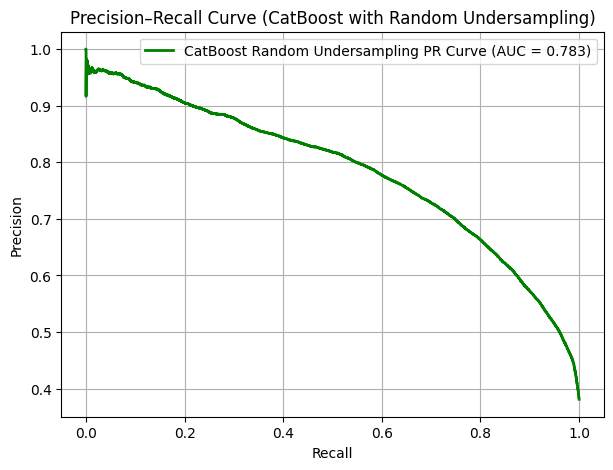

In [133]:
# 1️⃣ Compute precision, recall, and thresholds
precision_rus, recall_rus, thresholds_rus = precision_recall_curve(y_test, y_proba_cb)

# 3️⃣ Plot the Precision–Recall curve
plt.figure(figsize=(7,5))
plt.plot(recall_rus, precision_rus, color='green', linewidth=2,
         label=f"CatBoost Random Undersampling PR Curve (AUC = {pr_auc_Rus:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (CatBoost with Random Undersampling)")
plt.legend()
plt.grid(True)
plt.show()

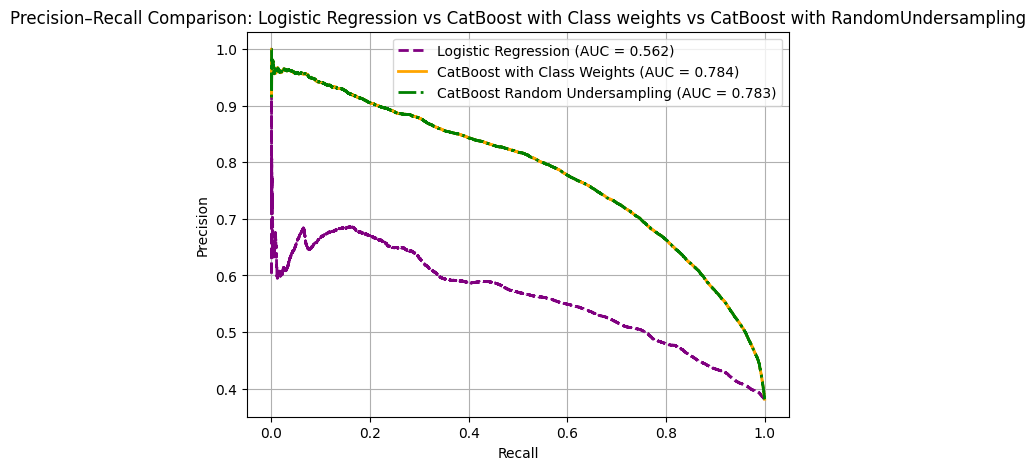

In [134]:
# comparison of PR-AUC curve among three techniques
plt.figure(figsize=(7,5))
plt.plot(recall, precision, color='purple', linewidth=2, linestyle='--', label=f"Logistic Regression (AUC = {pr_auc:.3f})")
plt.plot(recall_cb, precision_cb, color='orange', linewidth=2, linestyle='-', label=f"CatBoost with Class Weights (AUC = {pr_auc_cb:.3f})")
plt.plot(recall_rus, precision_rus, color='green', linewidth=2, linestyle='-.', label=f"CatBoost Random Undersampling (AUC = {pr_auc_Rus:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Comparison: Logistic Regression vs CatBoost with Class weights vs CatBoost with RandomUndersampling")
plt.legend()
plt.grid(True)
plt.show()


In [135]:
#SMOTE NC
smotedf = df.copy()

In [136]:
smotedf.head()

,InscClaimAmtReimbursed,ClmAdmitDiagnosisCode,DeductibleAmtPaid,DiagnosisGroupCode,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,...,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,PotentialFraud,Claim_Duration,Lengthofstay,Age,IsDead,Annual_Reimb_Total,Annual_Deduct_Total
0,26000,7866,1068.0,201,1,1,0,39,230,12,...,2,1,1,1,6,6.0,66,0,36060,3274
1,5000,6186,1068.0,750,1,1,0,39,230,12,...,2,1,1,0,2,2.0,66,0,36060,3274
2,5000,29590,1068.0,883,1,1,0,39,230,12,...,2,1,1,0,3,3.0,66,0,36060,3274
3,5000,431,1068.0,067,2,2,0,1,360,12,...,2,1,1,0,8,8.0,94,0,5250,1388
4,10000,78321,1068.0,975,2,1,1,45,780,12,...,2,2,2,0,17,17.0,71,0,21380,2236


In [137]:
drop_cols = ['ClmAdmitDiagnosisCode', 'DiagnosisGroupCode', 'State', 'County']
smotedf = smotedf.drop(columns=[c for c in drop_cols if c in smotedf.columns])
y = smotedf['PotentialFraud']
X = smotedf.drop(['PotentialFraud'], axis =1)

# splitting into TRain and test
X_train_smote, X_test_smote, y_train_smote, y_test_smote = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  
)


In [138]:
X_train_smote['Lengthofstay']=X_train_smote['Lengthofstay'].fillna(0)

In [139]:
check_missing(X_train_smote, "training set")


Missing Values in training set:
✅ No missing values


In [140]:
# --- 4. Apply SMOTE on the training set only ---
smote = SMOTE(sampling_strategy=1, k_neighbors=3,random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_smote, y_train_smote)

print("Before SMOTE:", y_train_smote.value_counts().to_dict())
print("After SMOTE :", y_train_res.value_counts().to_dict())

# --- 5. Train CatBoost model ---
model = CatBoostClassifier(
    iterations=1000,
    depth=6,
    learning_rate=0.05,
    loss_function='Logloss',
    eval_metric='F1',
    random_seed=42,
    verbose=False
)

model.fit(X_train_res, y_train_res)


Before SMOTE: {0: 276332, 1: 170236}
After SMOTE : {0: 276332, 1: 276332}


In [141]:
# --- 6. Evaluate on test set ---
y_pred_smote= model.predict(X_test_smote)
y_proba_smote = model.predict_proba(X_test_smote)[:, 1]

cm = confusion_matrix(y_test_smote, y_pred_smote)
print("Confusion Matrix Of SMOTE CatBoost:\n", cm)
precision_smote = precision_score(y_test_smote, y_pred_smote)
print("Precision Of SMOTE CatBoost:", precision_smote)
recall_smote= recall_score(y_test_smote, y_pred_smote)
print("Recall Of SMOTE CatBoost:", recall_smote)
roc_auc_smote = roc_auc_score(y_test_smote, y_proba_smote)
print("ROC-AUC Score Of SMOTE CatBoost:", roc_auc_smote)
pr_auc_smote = average_precision_score(y_test_smote, y_proba_smote)
print("PR-AUC Score Of SMOTE CatBoost:", pr_auc_smote)

Confusion Matrix Of SMOTE CatBoost:
 [[56192 12891]
 [31852 10708]]
Precision Of SMOTE CatBoost: 0.4537480401711937
Recall Of SMOTE CatBoost: 0.25159774436090226
ROC-AUC Score Of SMOTE CatBoost: 0.554142600504852
PR-AUC Score Of SMOTE CatBoost: 0.4315959182993
